<a href="https://colab.research.google.com/github/ramirezcarlos292/miaad_math_for_ai/blob/main/Tarea%208%20-%20Sentimiento%20acumulado/sentimiento_acumulado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importar Librerías

In [274]:
import sympy as sp
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sympy import symbols, exp, diff, simplify, pprint, latex, init_printing, solve, factorial

init_printing(use_unicode=True)

In [275]:
from google.colab import drive
drive.mount('/content/drive/')

!wget -P /content/drive/MyDrive/ClassFiles https://raw.githubusercontent.com/ramirezcarlos292/miaad_math_for_ai/refs/heads/main/Tarea%208%20-%20Sentimiento%20acumulado/compra_producto.csv

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
--2025-10-06 05:08:29--  https://raw.githubusercontent.com/ramirezcarlos292/miaad_math_for_ai/refs/heads/main/Tarea%208%20-%20Sentimiento%20acumulado/compra_producto.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 276 [text/plain]
Saving to: ‘/content/drive/MyDrive/ClassFiles/compra_producto.csv.102’

compra_producto.csv 100%[===================>]     276  --.-KB/s    in 0s      

2025-10-06 05:08:29 (3.13 MB/s) - ‘/content/drive/MyDrive/ClassFiles/compra_producto.csv.102’ saved [276/276]



## Leer DataFrame

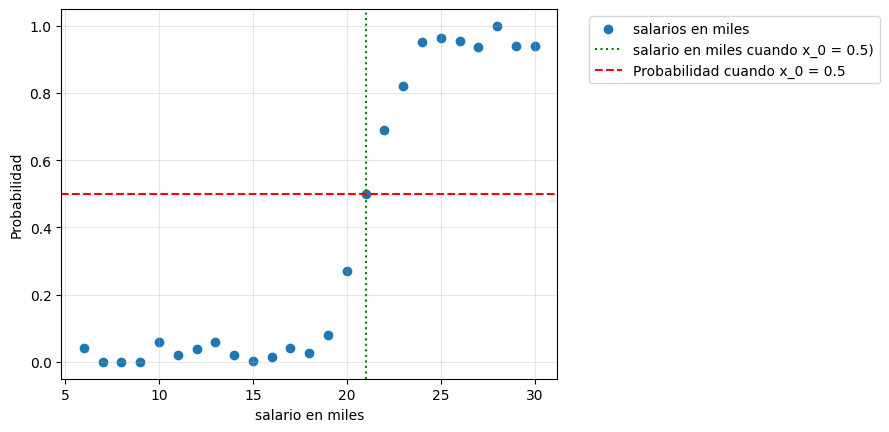

In [276]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/MIAAD/Math_MIA-0001-24/Tarea 8 - Sentimiento acumulado/compra_producto.csv')
# Graficar el salario en miles y la probabilidad
plt.scatter(y=df['Probabilidad'], x=df['salario en miles'], label='salarios en miles')
# salario alrededor de 0.5
# Valor de x_0 cuando la probabilidad es 0.5 o cerca de 0.5, en mi caso era 0.5 exacto.
p_0 = 0.5
x_at_0 = df['salario en miles'].loc[df['Probabilidad']==p_0]
x_at_0 = int(x_at_0.iloc[0])
plt.axvline(x_at_0, linestyle=':', color='green', label='salario en miles cuando x_0 = 0.5)')
plt.axhline(0.5, linestyle='--', color='red', label='Probabilidad cuando x_0 = 0.5')
plt.xlabel('salario en miles')
plt.ylabel('Probabilidad')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.grid(alpha=0.3)
plt.show()

In [277]:
# x min y x max para el problema de evaluar las integrales, estos vienen de los datos del problema
xmin = df['salario en miles'].min()
xmax = df['salario en miles'].max()

## Función

In [278]:
# Definir las variables simbólicas
x, x0 = symbols('x x_0')

# Definir la función sigmoide
f = 1 / (1 + exp(-(x - x0)))
f

     1      
────────────
 -x + x₀    
ℯ        + 1

## Series de Taylor

In [279]:
f_prime = diff(f, x)
f_prime_simplified = simplify(f_prime)

f_double_prime = diff(f_prime, x)
f_double_prime_simplified = simplify(f_double_prime)

f_triple_prime = diff(f_double_prime, x)
f_triple_prime_simplified = simplify(f_triple_prime)

# Series de Taylor
f1 = f_prime.subs({x0: x_at_0})
f2 = f_double_prime_simplified.subs({x0: x_at_0})
f3 = f_triple_prime_simplified.subs({x0: x_at_0})

st = f + f1*(x-x0) + f2/2*(x-x0)**2 + f3/6*(x-x0)**3
st

                                            ⎛             2            ⎞       ↪
⎛     x - 21⎞         2  x - 21           3 ⎜⎛ x - 21    ⎞       x - 21⎟  x -  ↪
⎝1 - ℯ      ⎠⋅(x - x₀) ⋅ℯ         (x - x₀) ⋅⎝⎝ℯ       + 1⎠  - 6⋅ℯ      ⎠⋅ℯ     ↪
─────────────────────────────── + ──────────────────────────────────────────── ↪
                      3                                         4              ↪
         ⎛ x - 21    ⎞                             ⎛ x - 21    ⎞               ↪
       2⋅⎝ℯ       + 1⎠                           6⋅⎝ℯ       + 1⎠               ↪

↪                                     
↪ 21             21 - x               
↪      (x - x₀)⋅ℯ              1      
↪ ── + ──────────────── + ────────────
↪                    2     -x + x₀    
↪       ⎛ 21 - x    ⎞     ℯ        + 1
↪       ⎝ℯ       + 1⎠                 

## Integración
Para calcular el sentimiento I en el intervalo de salarios dado.

#### 1. Método de sumas de Riemann

In [280]:
# Determinar el rango a realizar las sumas de riemann
def getXRange(xmin, xmax, N, mode):
    dx = (xmax - xmin) / N
    x = np.linspace(xmin, xmax-dx, N)
    if mode == 'left':
      x = x
    elif mode == 'mid':
      x+=dx/2.0
    elif mode == 'right':
      x+=dx
    else:
      x = x
    return x

def sum_riemann_process(f, xmin, xmax, df, funcion, metodo):
  N = 10

  # create equally spaced x values
  xplot=np.linspace(xmin, xmax, np.max(N)* 10) # generar una lista de valores en el rango deseado
  yplot = [f.subs({x: x_p, x0: x_at_0}).evalf() for x_p in xplot]
  yplot

  # # Obtener el rango para la técnica a utilizar, izquierda, mitad o derecha
  x_left_test = getXRange(xmin, xmax, N, 'left')
  y_left_test = [f.subs({x: x_p, x0: x_at_0}).evalf() for x_p in x_left_test]

  x_mid_test = getXRange(xmin, xmax, N, 'mid')
  y_mid_test = [f.subs({x: x_p, x0: x_at_0}).evalf() for x_p in x_mid_test]

  x_right_test = getXRange(xmin, xmax, N, 'right')
  y_right_test = [f.subs({x: x_p, x0: x_at_0}).evalf() for x_p in x_right_test]


  # # Calcular el tamanio de la base de los rectangulos
  dx = x_left_test[1] - x_left_test[0]
  print(f"{funcion}\n")
  print(f)
  print(f"{metodo}")
  print(f"\t{dx*np.sum(y_mid_test)}")
  # print((dx*np.sum(y_left_test)+dx*np.sum(y_mid_test)+dx*np.sum(y_right_test))/3)

  # # Graficar los rectangulos bajo la curva
  plt.figure()
  plt.plot(xplot, yplot, 'r-', label='función a estimar área bajo la curva')
  # plt.bar(x_left_test+dx/2, y_mid_test, dx, alpha=0.5, label='left', color='orange')
  plt.bar(x_mid_test, y_mid_test, dx, alpha=0.5, label='aproximación area bajo la curva usando punto medio')
  # plt.bar(x_right_test-dx/2, y_right_test, dx, alpha=0.5, label='right')
  plt.xlabel('salario en miles')
  plt.ylabel('Probabilidad')
  plt.grid(alpha=0.3)
  plt.legend(bbox_to_anchor=(1.05, 1))
  plt.show()

Funcion Sigmoide

1/(exp(-x + x_0) + 1)
Area bajo la curva usando rectangulos:
	9.00346515559782


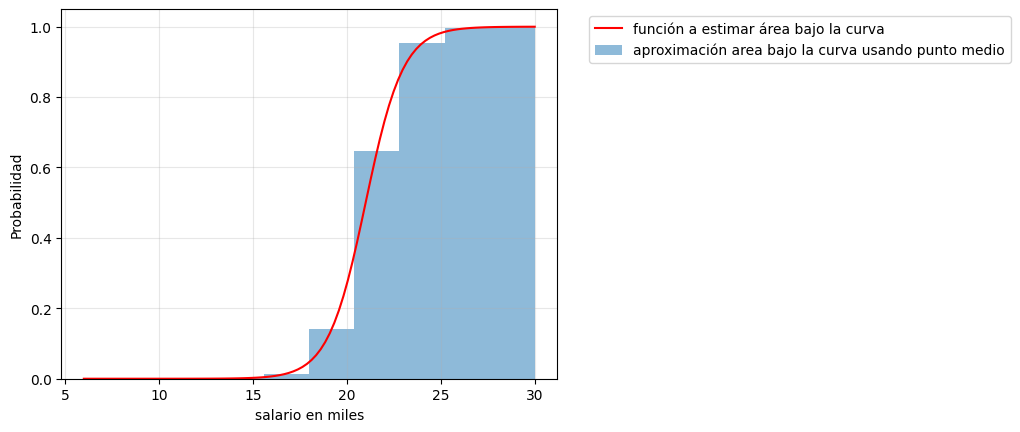

In [281]:
metodo = 'Area bajo la curva usando rectangulos:'
funcion = 'Funcion Sigmoide'
sum_riemann_process(f, xmin, xmax, df, funcion, metodo)

Funcion Series de Taylor

(1 - exp(x - 21))*(x - x_0)**2*exp(x - 21)/(2*(exp(x - 21) + 1)**3) + (x - x_0)**3*((exp(x - 21) + 1)**2 - 6*exp(x - 21))*exp(x - 21)/(6*(exp(x - 21) + 1)**4) + (x - x_0)*exp(21 - x)/(exp(21 - x) + 1)**2 + 1/(exp(-x + x_0) + 1)
Area bajo la curva usando rectangulos:
	9.12549673623483


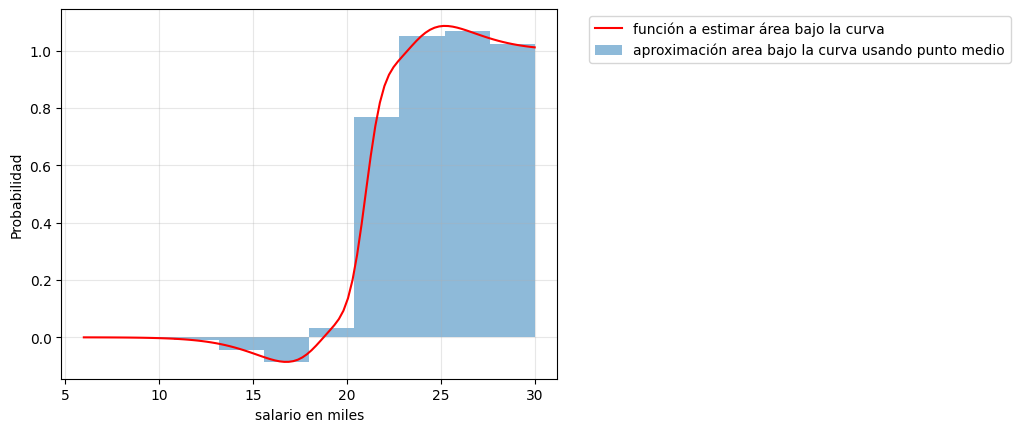

In [282]:
metodo = 'Area bajo la curva usando rectangulos:'
funcion = 'Funcion Series de Taylor'
sum_riemann_process(st, xmin, xmax, df, funcion, metodo)

#### 2. Método de los trapecios

In [283]:
# Determinar el rango a realizar las sumas de riemann
def getXRange(xmin, xmax, N):
    dx = (xmax - xmin) / N
    x = np.linspace(xmin, xmax-dx, N)
    return x

def sum_trapezoid_process(f, xmin, xmax, df, funcion, metodo):
  N = 10

  # Crear x y evaluar la funcion para obtener valores de y
  xplot=np.linspace(xmin, xmax, np.max(N)* 10) # generar una lista de valores en el rango deseado
  yplot = [f.subs({x: x_p, x0: x_at_0}).evalf() for x_p in xplot]


  # # Obtener el rango y el dominio para los trapecios
  x_test = getXRange(xmin, xmax, N)
  y_test = [f.subs({x: x_p, x0: x_at_0}).evalf() for x_p in x_test]


  # # # Calcular el tamanio de la base de los trapecios
  dx = x_test[1] - x_test[0]
  print(f"{funcion}\n")
  print(f)
  print(f"{metodo}")

  # desfase para graficar trapecios
  lastx = x_test[-1]
  x_test_1 = x_test[1:]
  x_test_1 = np.append(x_test_1, lastx)
  lasty = y_test[-1]
  y_test_1 = y_test[1:]
  y_test_1 = np.append(y_test_1, lasty)

  # Calcular las alturas de los trapecios
  y_height = []
  for idx in range(len(y_test)):
    y_height.append((y_test[idx]+y_test_1[idx])/2)

  # Realizar la suma de las areas de los trapecios
  print(f"\t{dx*np.sum(y_height)}")


  # # # Graficar los rectangulos bajo la curva
  plt.figure()
  plt.plot(xplot, yplot, label='función a calcular área bajo la curva', linestyle=':',color='red')
  plt.plot(x_test_1, y_test_1, label='área bajo la curva con método de trapecios')
  plt.xlabel('salario en miles')
  plt.ylabel('Probabilidad')
  plt.legend(bbox_to_anchor=(1.05, 1))
  plt.grid(alpha=0.3)
  plt.show()

Funcion Sigmoide

1/(exp(-x + x_0) + 1)
Area bajo la curva usando trapecios:
	8.99532773916090


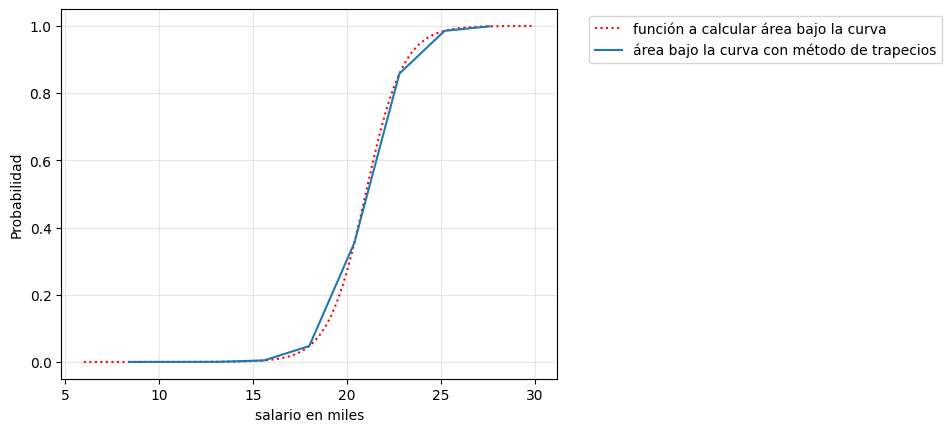

In [284]:
metodo = 'Area bajo la curva usando trapecios:'
funcion = 'Funcion Sigmoide'
sum_trapezoid_process(f, xmin, xmax, df, funcion, metodo)

Funcion Series de Taylor

(1 - exp(x - 21))*(x - x_0)**2*exp(x - 21)/(2*(exp(x - 21) + 1)**3) + (x - x_0)**3*((exp(x - 21) + 1)**2 - 6*exp(x - 21))*exp(x - 21)/(6*(exp(x - 21) + 1)**4) + (x - x_0)*exp(21 - x)/(exp(21 - x) + 1)**2 + 1/(exp(-x + x_0) + 1)
Area bajo la curva usando trapecios:
	8.87899039437403


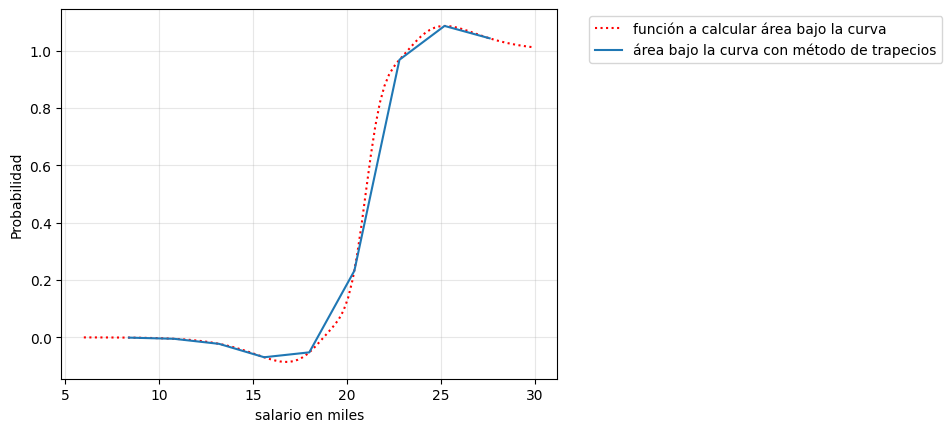

In [285]:
metodo = 'Area bajo la curva usando trapecios:'
funcion = 'Funcion Series de Taylor'
sum_trapezoid_process(st, xmin, xmax, df, funcion, metodo)


#### 3. AUC usando integración númerica para la función sigmoide
Integrando directamente la función, donde s0 es el punto que escogió para obtener el desarrollo de Taylor.

In [286]:
def numerical_integration(f, xmin, xmax, df, title):
  func_a = f.subs({x0: x_at_0})
  func_i = sp.integrate(func_a)
  print(f"Primera Integral: ")
  print(func_i)

  # evaluar la integral de la funcion sigmoide
  area = sp.integrate(func_a, (x, xmin, xmax)).evalf()
  print(f"Area bajo la curva evaluada: {area:.5f}")

  # Crear un rango de valores de x para el área sombreada
  x_space = np.linspace(xmin, xmax, 500)
  f_numeric = sp.lambdify(x, f.subs(x0, x_at_0), 'numpy')
  y_space = f_numeric(x_space)
  x_sombreado = np.linspace(xmin, xmax, 500)
  y_sombreado = f_numeric(x_sombreado)

  # Crear la gráfica
  plt.figure(figsize=(8, 6))
  plt.plot(x_space, y_space, label="Función", color="blue")  # Curva principal
  plt.fill_between(x_sombreado, y_sombreado, color="skyblue", alpha=0.5, label="Área bajo la curva")  # Área sombreada

  x1 = list(df['salario en miles'])
  y1 = list(df['Probabilidad'])
  plt.scatter(x1, y1, label='probabilidad')
  # Añadir etiquetas y leyenda
  plt.title(f"Área bajo la curva {title}")
  plt.xlabel("x")
  plt.ylabel("f(x)")
  plt.axhline(0, color="black", linewidth=0.8, linestyle="--")  # Línea horizontal en y=0
  plt.legend(bbox_to_anchor=(1.05, 1))
  plt.grid(alpha=0.3)

  # # Mostrar la gráfica
  plt.show()

  return func_i, area

Primera Integral: 
x + log(exp(21 - x) + 1)
Area bajo la curva evaluada: 9.00012


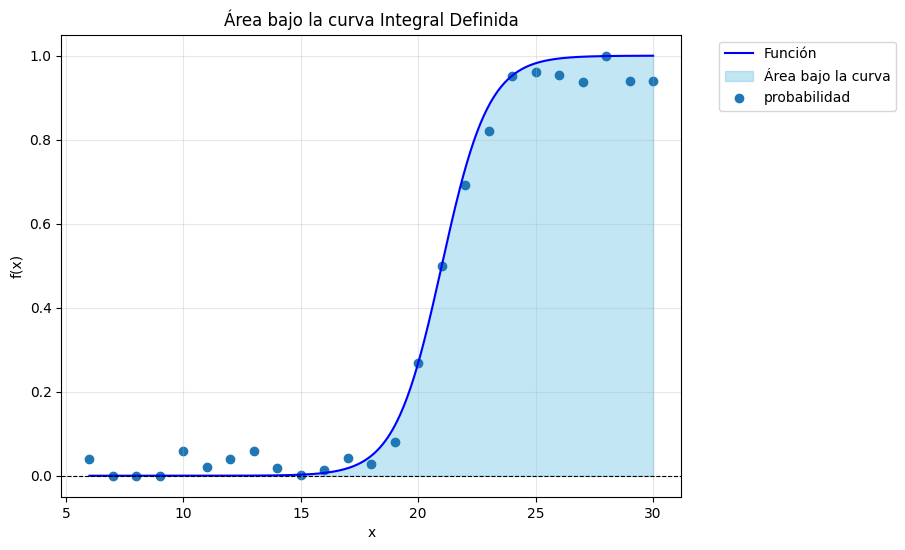

In [287]:
func_i, area = numerical_integration(f, xmin, xmax, df, 'Integral Definida')

#### 4. AUC usando integración númerica para la aproximación de Taylor

Primera Integral: 
(3*x + (-x**3/2 + 63*x**2/2 - 1311*x/2 + 9009/2)*exp(21 - x) + (x**3/2 - 63*x**2/2 + 1329*x/2 - 9387/2)*exp(42 - 2*x) - 63)/(9*exp(21 - x) + 9*exp(42 - 2*x) + 3*exp(63 - 3*x) + 3)
Area bajo la curva evaluada: 8.98408


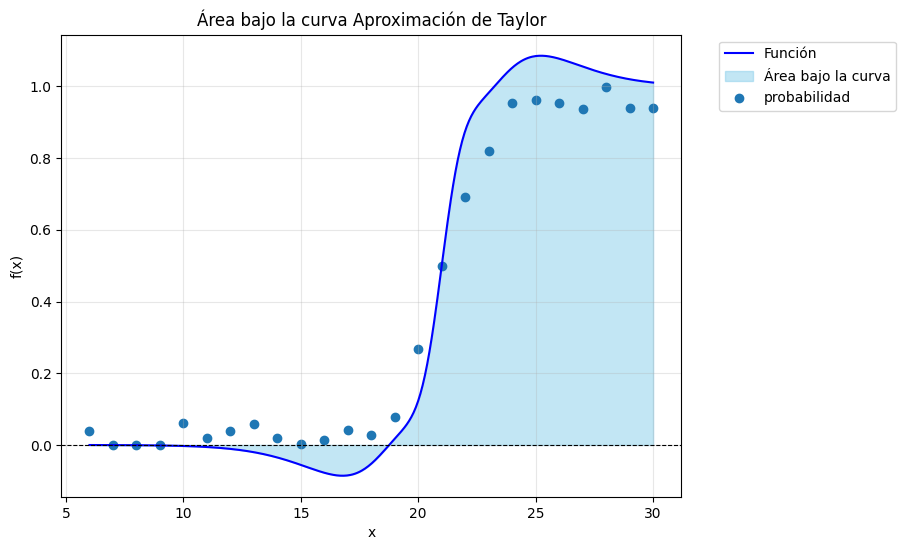

In [288]:
st_i, area = numerical_integration(st, xmin, xmax, df, 'Aproximación de Taylor')

#### 5. Evaluar las integrales de la función sigmoide y la aproximación de taylor

In [289]:
# primera integral
func_i

       ⎛ 21 - x    ⎞
x + log⎝ℯ       + 1⎠

In [290]:
salarios = list(df['salario en miles'])
proba = list(df['Probabilidad'])
reales = []
for idx in range(len(salarios)):
  salario, prob = salarios[idx], proba[idx]
  value = func_i.subs({x: salario}).evalf()
  # if prob < p_0:
  value -= 21
  reales.append(value/10)

df_reales = pd.DataFrame({"probabilidad por integracion numerica": reales})
df = pd.concat([df, df_reales], axis=1)
df.tail()

,salario en miles,Probabilidad,probabilidad por integracion numerica
20,26,0.9533,0.500671534848912
21,27,0.9375,0.600247568513773
22,28,0.9991,0.700091146645378
23,29,0.9397,0.800033540637289
24,30,0.9399,0.900012340218972


In [291]:
st_i

      ⎛   3       2                ⎞           ⎛ 3       2                ⎞    ↪
      ⎜  x    63⋅x    1311⋅x   9009⎟  21 - x   ⎜x    63⋅x    1329⋅x   9387⎟  4 ↪
3⋅x + ⎜- ── + ───── - ────── + ────⎟⋅ℯ       + ⎜── - ───── + ────── - ────⎟⋅ℯ  ↪
      ⎝  2      2       2       2  ⎠           ⎝2      2       2       2  ⎠    ↪
────────────────────────────────────────────────────────────────────────────── ↪
                           21 - x      42 - 2⋅x      63 - 3⋅x                  ↪
                        9⋅ℯ       + 9⋅ℯ         + 3⋅ℯ         + 3              ↪

↪             
↪ 2 - 2⋅x     
↪         - 63
↪             
↪ ────────────
↪             
↪             

In [292]:
salarios = list(df['salario en miles'])
proba = list(df['Probabilidad'])

approx = []
for idx in range(len(salarios)):
  salario, prob = salarios[idx], proba[idx]
  value = st_i.subs({x: salario}).evalf()
  approx.append(value/10)

df_aproximados = pd.DataFrame({"probabilidad por aproximaciones de taylor": approx})
df = pd.concat([df, df_aproximados], axis=1)
df.tail()

,salario en miles,Probabilidad,probabilidad por integracion numerica,probabilidad por aproximaciones de taylor
20,26,0.9533,0.500671534848912,0.482988850024686
21,27,0.9375,0.600247568513773,0.589680903642650
22,28,0.9991,0.700091146645378,0.694168314268423
23,29,0.9397,0.800033540637289,0.796872943773914
24,30,0.9399,0.900012340218972,0.898390255733493


### Calcular el valor absoluto de la diferencia entre los valores aproximados y reales

In [293]:
df['error absoluto'] = abs(df['probabilidad por integracion numerica'] - df['probabilidad por aproximaciones de taylor'])
df.head()

,salario en miles,Probabilidad,probabilidad por integracion numerica,probabilidad por aproximaciones de taylor,error absoluto
0,6,0.04,3.05902272401681e-8,-1.76658378139790e-5,1.76964280412191e-5
1,7,0.00,8.31528375044854e-8,-3.91925928385437e-5,3.92757456760481e-5
2,8,0.00,2.26032685191058e-7,-8.57034017321303e-5,8.59294344173214e-5
3,9,0.00,6.14419347755302e-7,-0.000184321976403636,0.000184936395751392
4,10,0.06,1.67015613179444e-6,-0.000388846208946429,0.000390516365078224


## Grafique los valores aproximados y los reales y analice el resultado

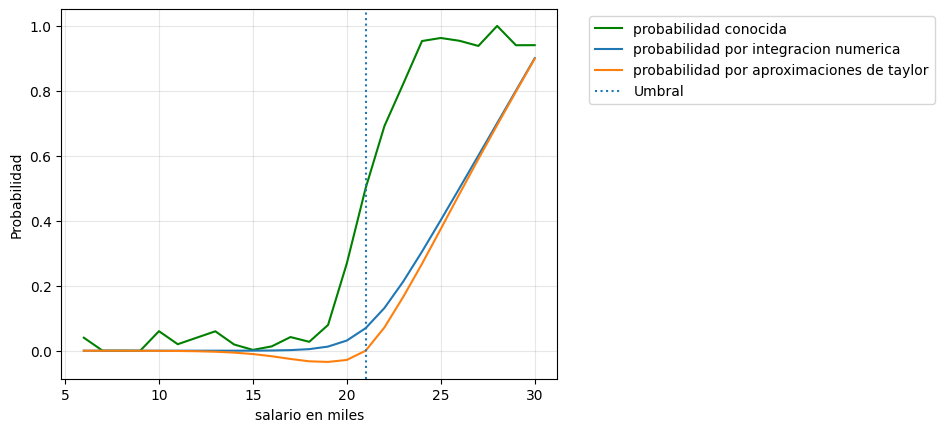

In [294]:
x = df['salario en miles']
y = df['Probabilidad']
y1 = df['probabilidad por integracion numerica']
y2 = df['probabilidad por aproximaciones de taylor']
plt.plot(x, y, label='probabilidad conocida', color='green')
plt.plot(x, y1, label='probabilidad por integracion numerica')
plt.plot(x, y2, label='probabilidad por aproximaciones de taylor')
plt.axvline(x_at_0, linestyle=':', label='Umbral')
plt.xlabel('salario en miles')
plt.ylabel('Probabilidad')
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

# Conclusión

En la tarea anterior, las derivadas nos permitieron modelar la Probabilidad dado un sueldo y las series de taylor nos ayudaron a aproximar esa probabilidad, las integrales en este ejercicio nos ayudaron a crear lo que he visto en Aprendizaje Profundo como funciónd de activación ReLU o GeLU, que en redes neuronales crea los thresholds para la activación de las neuronas para clasificar, que en este caso sería evaluar el sentimiento de compra (probabilidad) dado el sueldo.